In [ ]:

# CELL 1 — Imports

import random
import cv2
import numpy as np
import logging
from pathlib import Path
from typing import List, Tuple, Optional
from PIL import Image
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    logging.warning("numba not found — pip install numba. Falling back to numpy RLE.")

import time
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)


SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print("✓ Imports done.")
print(f"✓ Global seed set to {SEED}")

✓ Imports done.
✓ Global seed set to 42


In [ ]:
# CELL 2 — BUSI dataset loading
from PIL import Image
import os
import numpy as np

DATA_ROOT   = "D:/cancer-ultra sound/breast3/Dataset_BUSI_with_GT"
CLASS_NAMES = ['benign', 'malignant', 'normal']
NUM_CLASSES = len(CLASS_NAMES)

def load_busi(root):
    X, y = [], []
    for label, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(root, cls)
        for fname in sorted(os.listdir(folder)):
            # skip mask files — only load original images
            if fname.endswith('_mask.png') or fname.endswith('_mask.jpg'):
                continue
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                img = Image.open(os.path.join(folder, fname)).convert('L')
                X.append(np.array(img, dtype=np.uint8))
                y.append(label)
    return np.array(X, dtype=object), np.array(y, dtype=np.int64)

print("Loading BUSI images...")
X_train_raw, y_train_raw = load_busi(DATA_ROOT)

print(f"\nClasses     : {CLASS_NAMES}")
print(f"Total images: {len(X_train_raw)}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(y_train_raw==i).sum()} images")

Loading BUSI images...

Classes     : ['benign', 'malignant', 'normal']
Total images: 798
  benign: 454 images
  malignant: 211 images
  normal: 133 images


In [ ]:

# CELL 4 — Configuration

   
NUM_CLASSES = 3
CLASS_NAMES = ["benign", "malignant", "normal"]
CLASS_MAP   = {"benign": 0, "malignant": 1, "normal": 2}
IMAGE_SIZE  = 128   

# --- image / RLE knobs ---
MAX_RUNS       = 4
NEARFIELD_SKIP = 0.0
FARFIELD_SKIP  = 0.0

# --- derived (do not edit) ---
Y_START   = int(IMAGE_SIZE * NEARFIELD_SKIP)
Y_END     = int(IMAGE_SIZE * (1.0 - FARFIELD_SKIP))
CROP_ROWS = Y_END - Y_START
ROW_FEAT  = CROP_ROWS  * MAX_RUNS * 3
COL_FEAT  = IMAGE_SIZE * MAX_RUNS * 3

# --- model architecture knobs ---
CONV_CHANNELS = [16, 32,32]
CONV_KERNEL   = 3
POOL_OUT      = 2
FC_HIDDEN     = 128
FC_DROPOUT    = 0.05
CONV_DROPOUT  = 0.2

# --- training knobs ---
SEED             = 42
_aug_rng = np.random.default_rng(SEED)
BATCH_SIZE       = 64     
EPOCHS           = 100    
LR               = 6e-3
WEIGHT_DECAY     = 5e-3
PATIENCE         = 30
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED) 
# --- loss / imbalance ---
IMBALANCE_STRATEGY = "class_weight"
LOSS_FN            = "focal"
FOCAL_GAMMA        = 2.0
THRESH_K           = -0.1

# --- augmentation --- turn ON for small dataset
AUG_PARAMS = dict(
    flip_prob    = 0.3,
    rotate_prob  = 0.2,
    rotate_limit = 25,
)

NUM_DATALOADER_WORKERS = 0

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True

print("✓ Configuration set.")
print(f"  Device         : {DEVICE}")
print(f"  IMAGE_SIZE     : {IMAGE_SIZE}  MAX_RUNS={MAX_RUNS}  CROP_ROWS={CROP_ROWS}")
print(f"  ROW_FEAT       : {ROW_FEAT}   COL_FEAT={COL_FEAT}   TOTAL={ROW_FEAT+COL_FEAT}")
print(f"  NUM_CLASSES    : {NUM_CLASSES}  → {CLASS_NAMES}")
print(f"  BATCH={BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")
print(f"  AUG: flip={AUG_PARAMS['flip_prob']}  rotate={AUG_PARAMS['rotate_prob']}")

✓ Configuration set.
  Device         : cuda
  IMAGE_SIZE     : 128  MAX_RUNS=4  CROP_ROWS=128
  ROW_FEAT       : 1536   COL_FEAT=1536   TOTAL=3072
  NUM_CLASSES    : 3  → ['benign', 'malignant', 'normal']
  BATCH=64  LR=0.006  WD=0.005  EPOCHS=100  PATIENCE=30
  AUG: flip=0.3  rotate=0.2


In [ ]:

# CELL 5 — RLE helpers + augmentation

if HAS_NUMBA:
    @njit(parallel=True, cache=True)
    def _rle_numba(binary: np.ndarray, img_u8: np.ndarray, max_runs: int) -> np.ndarray:
        H, W = binary.shape
        out  = np.zeros((H, max_runs * 3), dtype=np.float32)
        for i in prange(H):
            in_run = False
            start  = 0
            run_n  = 0
            for j in range(W):
                val = binary[i, j]
                if val == 1 and not in_run:
                    start  = j
                    in_run = True
                elif val == 0 and in_run:
                    if run_n < max_runs:
                        length = j - start
                        total  = np.float32(0.0)
                        for k in range(length):
                            total += np.float32(img_u8[i, start + k])  
                        out[i, run_n * 3]     = np.float32(start)  / np.float32(W)
                        out[i, run_n * 3 + 1] = np.float32(length) / np.float32(W)
                        out[i, run_n * 3 + 2] = (total / np.float32(length)) / np.float32(255.0)
                        run_n += 1
                    in_run = False
            if in_run and run_n < max_runs:
                length = W - start
                total  = np.float32(0.0)
                for k in range(length):
                    total += np.float32(img_u8[i, start + k])          
                out[i, run_n * 3]     = np.float32(start)  / np.float32(W)
                out[i, run_n * 3 + 1] = np.float32(length) / np.float32(W)
                out[i, run_n * 3 + 2] = (total / np.float32(length)) / np.float32(255.0)
        return out

    def vectorized_rle(binary: np.ndarray,
                       img_u8: np.ndarray,
                       max_runs: int = MAX_RUNS) -> np.ndarray:
        return _rle_numba(np.ascontiguousarray(binary),
                          np.ascontiguousarray(img_u8.astype(np.uint8)),
                          max_runs)

else:
    def vectorized_rle(binary: np.ndarray,
                       img_u8: np.ndarray,
                       max_runs: int = MAX_RUNS) -> np.ndarray:
        H, W   = binary.shape
        out    = np.zeros((H, max_runs * 3), dtype=np.float32)
        padded = np.concatenate([
            np.zeros((H, 1), dtype=np.int8),
            binary.astype(np.int8),
            np.zeros((H, 1), dtype=np.int8),
        ], axis=1)
        diff = np.diff(padded, axis=1)
        img_f = img_u8.astype(np.float32)          
        for i in range(H):
            row    = diff[i]
            starts = np.where(row ==  1)[0]
            ends   = np.where(row == -1)[0]
            n      = min(len(starts), max_runs)
            if n == 0:
                continue
            lengths = (ends[:n] - starts[:n]).astype(np.float32)
            out[i, 0:n*3:3] = starts[:n].astype(np.float32) / W
            out[i, 1:n*3:3] = lengths / W
            for k in range(n):
                s = int(starts[k])
                l = int(lengths[k])
                out[i, k*3 + 2] = img_f[i, s:s+l].mean() / 255.0  
        return out


def _rle_from_array(img_arr: np.ndarray) -> np.ndarray:
    img_f     = img_arr.astype(np.float32)
    mean      = img_f.mean()
    std       = img_f.std()
    threshold = mean + THRESH_K * std
    binary    = (img_f < threshold).astype(np.uint8)
    img_u8    = img_arr.astype(np.uint8)

    rle_row = vectorized_rle(binary,
                             img_u8,
                             MAX_RUNS)
    rle_col = vectorized_rle(np.ascontiguousarray(binary.T),
                             np.ascontiguousarray(img_u8.T),
                             MAX_RUNS)
    return np.concatenate([rle_row.flatten(), rle_col.flatten()])


def _augment(img: np.ndarray) -> list:
    results = []
    if AUG_PARAMS['flip_prob'] > 0 and _aug_rng.random() < AUG_PARAMS['flip_prob']:
        results.append(np.fliplr(img))
    if AUG_PARAMS['rotate_prob'] > 0 and _aug_rng.random() < AUG_PARAMS['rotate_prob']:
        h, w  = img.shape
        angle = _aug_rng.uniform(-AUG_PARAMS['rotate_limit'],
                                  AUG_PARAMS['rotate_limit'])
        M     = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        results.append(cv2.warpAffine(img, M, (w, h),
                                      flags      = cv2.INTER_LINEAR,
                                      borderMode = cv2.BORDER_CONSTANT,
                                      borderValue= 0))
    return results

print("✓ RLE helpers defined.")

✓ RLE helpers defined.


  Using X_train_raw[0]
  Resized: (471, 562) → (128, 128)

  SINGLE IMAGE CONFIG CHECK
  IMAGE_SIZE     : 128
  MAX_RUNS       : 4
  THRESH_K       : -0.1
  NEARFIELD_SKIP : 0.0  →  Y_START=0
  FARFIELD_SKIP  : 0.0   →  Y_END=128
  CROP_ROWS      : 128
  Features/run   : 3  (start, length, avg_intensity)
  Total features : 3072  (expected ROW_FEAT+COL_FEAT=3072)

  Pixel stats (after resize+crop):
    mean      : 132.38
    std       : 56.88
    threshold : 138.06  (mean - -0.1*std)
    foreground pixels (binary=1): 7959 / 16384  (48.6%)

  RLE run usage:
    Row — max runs used : 4  / MAX_RUNS=4  (CLIPPING ✗ — increase MAX_RUNS)
    Col — max runs used : 4  / MAX_RUNS=4  (CLIPPING ✗ — increase MAX_RUNS)
    Avg runs/row        : 2.84
    Avg runs/col        : 4.00

  Non-zero feature ratio : 82.55%  (CHECK THRESH_K ✗)
  Reconstruction accuracy: 93.68%  (OK ✓)

  DIAGNOSIS:
  ✗ Row runs clipping at MAX_RUNS=4 — increase MAX_RUNS
  ✗ Col runs clipping at MAX_RUNS=4 — increase MAX_RUNS


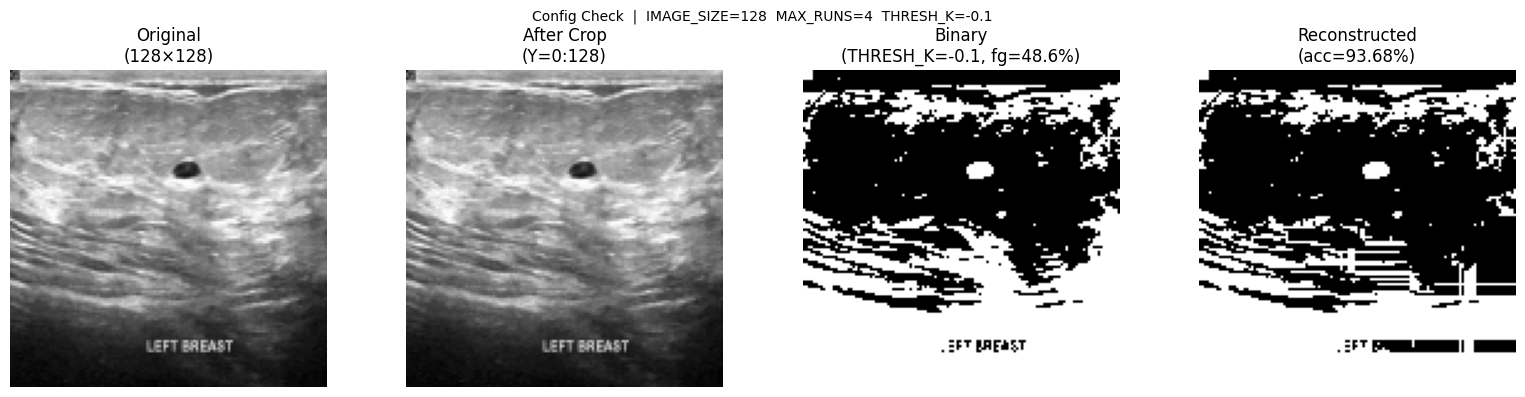

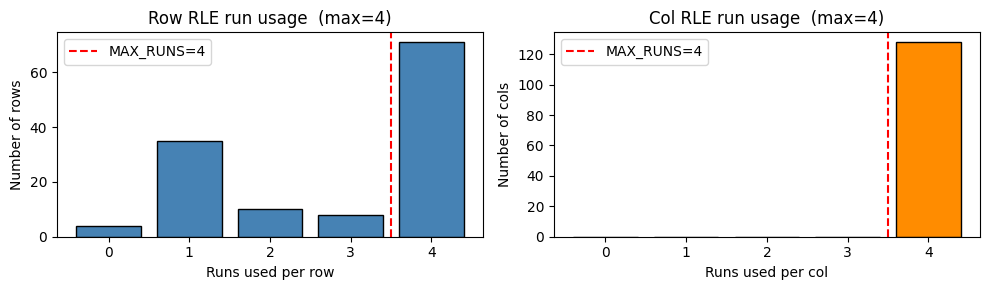

In [ ]:
# CELL 4B — Single Image Reconstruction Check
import matplotlib.pyplot as plt
import cv2

def check_single_image_reconstruction(img_input=None, show_stats=True):

    if img_input is None:
        if 'X_train_raw' in dir() or 'X_train_raw' in globals():
            img_input = X_train_raw[0]
            print(f"  Using X_train_raw[0]")
        else:
            print("  ERROR: No image source found. Pass an image array directly.")
            return

    img = np.array(img_input, dtype=np.uint8)

    original_shape = img.shape
    if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
        print(f"  Resized: {original_shape} → {img.shape}")
    else:
        print(f"  Shape OK: {img.shape} (no resize needed)")

    img_cropped = img[Y_START:Y_END, :]
    img_u8      = img_cropped.astype(np.uint8)          

    img_f     = img_cropped.astype(np.float32)
    mean_val  = img_f.mean()
    std_val   = img_f.std()
    threshold = mean_val - THRESH_K * std_val
    binary    = (img_f < threshold).astype(np.uint8)

    # ── RLE extraction — pass img_u8 for intensity ────────────────────────
    rle_row = vectorized_rle(binary,                          img_u8,   MAX_RUNS)
    rle_col = vectorized_rle(np.ascontiguousarray(binary.T), np.ascontiguousarray(img_u8.T), MAX_RUNS)
    raw_features = np.concatenate([rle_row.flatten(), rle_col.flatten()])

    # ── reconstruction — index is now *3 instead of *2 ───────────────────
    H, W          = img_cropped.shape
    reconstructed = np.zeros((H, W), dtype=np.uint8)

    for i in range(H):
        for j in range(MAX_RUNS):
            start  = int(rle_row[i, j * 3]     * W)
            length = int(rle_row[i, j * 3 + 1] * W)
            if length > 0:
                reconstructed[i, start:min(start + length, W)] = 1

    for j in range(W):
        for k in range(MAX_RUNS):
            start  = int(rle_col[j, k * 3]     * H)
            length = int(rle_col[j, k * 3 + 1] * H)
            if length > 0:
                reconstructed[start:min(start + length, H), j] = 1

    recon_acc = (binary == reconstructed).mean()

    # ── run statistics — length is now at index *3+1 ─────────────────────
    runs_per_row = []
    for i in range(H):
        used = sum(1 for j in range(MAX_RUNS) if rle_row[i, j * 3 + 1] > 0)
        runs_per_row.append(used)
    runs_per_row = np.array(runs_per_row)

    runs_per_col = []
    for j in range(W):
        used = sum(1 for k in range(MAX_RUNS) if rle_col[j, k * 3 + 1] > 0)
        runs_per_col.append(used)
    runs_per_col = np.array(runs_per_col)

    non_zero_ratio = (raw_features > 0.001).mean()

    if show_stats:
        print(f"\n{'='*55}")
        print(f"  SINGLE IMAGE CONFIG CHECK")
        print(f"{'='*55}")
        print(f"  IMAGE_SIZE     : {IMAGE_SIZE}")
        print(f"  MAX_RUNS       : {MAX_RUNS}")
        print(f"  THRESH_K       : {THRESH_K}")
        print(f"  NEARFIELD_SKIP : {NEARFIELD_SKIP}  →  Y_START={Y_START}")
        print(f"  FARFIELD_SKIP  : {FARFIELD_SKIP}   →  Y_END={Y_END}")
        print(f"  CROP_ROWS      : {CROP_ROWS}")
        print(f"  Features/run   : 3  (start, length, avg_intensity)")
        print(f"  Total features : {len(raw_features)}  "
              f"(expected ROW_FEAT+COL_FEAT={ROW_FEAT+COL_FEAT})")
        print(f"\n  Pixel stats (after resize+crop):")
        print(f"    mean      : {mean_val:.2f}")
        print(f"    std       : {std_val:.2f}")
        print(f"    threshold : {threshold:.2f}  (mean - {THRESH_K}*std)")
        print(f"    foreground pixels (binary=1): "
              f"{binary.sum()} / {binary.size}  "
              f"({binary.mean():.1%})")
        print(f"\n  RLE run usage:")
        print(f"    Row — max runs used : {runs_per_row.max()}  "
              f"/ MAX_RUNS={MAX_RUNS}  "
              f"({'OK ✓' if runs_per_row.max() < MAX_RUNS else 'CLIPPING ✗ — increase MAX_RUNS'})")
        print(f"    Col — max runs used : {runs_per_col.max()}  "
              f"/ MAX_RUNS={MAX_RUNS}  "
              f"({'OK ✓' if runs_per_col.max() < MAX_RUNS else 'CLIPPING ✗ — increase MAX_RUNS'})")
        print(f"    Avg runs/row        : {runs_per_row.mean():.2f}")
        print(f"    Avg runs/col        : {runs_per_col.mean():.2f}")
        print(f"\n  Non-zero feature ratio : {non_zero_ratio:.2%}  "
              f"({'OK ✓' if 0.05 < non_zero_ratio < 0.8 else 'CHECK THRESH_K ✗'})")
        print(f"  Reconstruction accuracy: {recon_acc:.2%}  "
              f"({'OK ✓' if recon_acc > 0.85 else 'LOW ✗ — check MAX_RUNS / THRESH_K'})")

        print(f"\n  DIAGNOSIS:")
        issues = 0
        if binary.mean() < 0.02:
            print(f"  ✗ Binary image almost empty — THRESH_K={THRESH_K} too low, increase it")
            issues += 1
        if binary.mean() > 0.95:
            print(f"  ✗ Binary image almost full  — THRESH_K={THRESH_K} too high, decrease it")
            issues += 1
        if runs_per_row.max() >= MAX_RUNS:
            print(f"  ✗ Row runs clipping at MAX_RUNS={MAX_RUNS} — increase MAX_RUNS")
            issues += 1
        if runs_per_col.max() >= MAX_RUNS:
            print(f"  ✗ Col runs clipping at MAX_RUNS={MAX_RUNS} — increase MAX_RUNS")
            issues += 1
        if recon_acc < 0.85:
            print(f"  ✗ Reconstruction < 85% — likely MAX_RUNS too small")
            issues += 1
        if non_zero_ratio < 0.05:
            print(f"  ✗ Too sparse — image may be nearly blank after binarization")
            issues += 1
        if issues == 0:
            print(f"  ✓ All checks passed — config looks good for full extraction")
        print(f"{'='*55}")

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img,           cmap='gray'); axes[0].set_title(f'Original\n({IMAGE_SIZE}×{IMAGE_SIZE})');              axes[0].axis('off')
    axes[1].imshow(img_cropped,   cmap='gray'); axes[1].set_title(f'After Crop\n(Y={Y_START}:{Y_END})');                  axes[1].axis('off')
    axes[2].imshow(binary,        cmap='gray'); axes[2].set_title(f'Binary\n(THRESH_K={THRESH_K}, fg={binary.mean():.1%})'); axes[2].axis('off')
    axes[3].imshow(reconstructed, cmap='gray'); axes[3].set_title(f'Reconstructed\n(acc={recon_acc:.2%})');                axes[3].axis('off')
    plt.suptitle(f'Config Check  |  IMAGE_SIZE={IMAGE_SIZE}  MAX_RUNS={MAX_RUNS}  THRESH_K={THRESH_K}', fontsize=10)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].bar(range(MAX_RUNS + 1),
                np.bincount(runs_per_row, minlength=MAX_RUNS + 1),
                color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Runs used per row')
    axes[0].set_ylabel('Number of rows')
    axes[0].set_title(f'Row RLE run usage  (max={runs_per_row.max()})')
    axes[0].axvline(MAX_RUNS - 0.5, color='red', linestyle='--', label=f'MAX_RUNS={MAX_RUNS}')
    axes[0].legend()

    axes[1].bar(range(MAX_RUNS + 1),
                np.bincount(runs_per_col, minlength=MAX_RUNS + 1),
                color='darkorange', edgecolor='black')
    axes[1].set_xlabel('Runs used per col')
    axes[1].set_ylabel('Number of cols')
    axes[1].set_title(f'Col RLE run usage  (max={runs_per_col.max()})')
    axes[1].axvline(MAX_RUNS - 0.5, color='red', linestyle='--', label=f'MAX_RUNS={MAX_RUNS}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'recon_accuracy' : recon_acc,
        'non_zero_ratio' : non_zero_ratio,
        'max_row_runs'   : runs_per_row.max(),
        'max_col_runs'   : runs_per_col.max(),
        'fg_ratio'       : binary.mean(),
        'threshold'      : threshold,
        'feature_dim'    : len(raw_features),
    }


config_check = check_single_image_reconstruction()

In [ ]:
# CELL 6 — Feature extraction + caching  (BUSI — with train/test split)


from sklearn.model_selection import train_test_split

CACHE_DIR       = Path("./cache_busi")
CACHE_DIR.mkdir(exist_ok=True)
FORCE_RECOMPUTE = True   


def extract_sequential(images: np.ndarray,
                        labels: np.ndarray,
                        is_train: bool) -> Tuple[list, list]:
    feats, out_labels = [], []
    desc = "train" if is_train else "other"
    for img, label in tqdm(zip(images, labels), total=len(images),
                           desc=f"  RLE {desc}"):
        img = img.astype(np.uint8)
        if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE),
                             interpolation=cv2.INTER_AREA)
        img = img[Y_START:Y_END, :]
        feats.append(_rle_from_array(img).astype(np.float32))
        out_labels.append(int(label))
        if is_train:
            for aug in _augment(img):
                feats.append(_rle_from_array(aug).astype(np.float32))
                out_labels.append(int(label))
    return feats, out_labels


cache_paths = {
    'X_train': CACHE_DIR / "X_train.npy",
    'y_train': CACHE_DIR / "y_train.npy",
    'X_test' : CACHE_DIR / "X_test.npy",
    'y_test' : CACHE_DIR / "y_test.npy",
}

if not FORCE_RECOMPUTE and all(f.exists() for f in cache_paths.values()):
    print("Loading features from cache...")
    X_train = np.load(cache_paths['X_train'])
    y_train = np.load(cache_paths['y_train'])
    X_test  = np.load(cache_paths['X_test'])
    y_test  = np.load(cache_paths['y_test'])
    print(f"  Train: {X_train.shape}  Test: {X_test.shape}")

else:
    print("Extracting RLE features from scratch...")
    print(f"  flip={AUG_PARAMS['flip_prob']}  rotate={AUG_PARAMS['rotate_prob']}  "
          f"MAX_RUNS={MAX_RUNS}  THRESH_K={THRESH_K}")

    # ── 80/20 stratified split on raw images BEFORE extraction ───────────────
    idx_tr, idx_te = train_test_split(
        np.arange(len(X_train_raw)),
        test_size    = 0.2,
        stratify     = y_train_raw,
        random_state = SEED,
    )
    print(f"  Split → train={len(idx_tr)}  test={len(idx_te)}")

    print(f"\n[1/3] Train ({len(idx_tr)} images)...")
    tf, tl = extract_sequential(X_train_raw[idx_tr], y_train_raw[idx_tr], True)

    print(f"\n[2/3] Test ({len(idx_te)} images)...")
    tft, tlt = extract_sequential(X_train_raw[idx_te], y_train_raw[idx_te], False)

    print("\n[3/3] Combining + saving...")
    X_train = np.array(tf,  dtype=np.float32)
    y_train = np.array(tl,  dtype=np.int64)
    X_test  = np.array(tft, dtype=np.float32)
    y_test  = np.array(tlt, dtype=np.int64)
    np.save(cache_paths['X_train'], X_train)
    np.save(cache_paths['y_train'], y_train)
    np.save(cache_paths['X_test'],  X_test)
    np.save(cache_paths['y_test'],  y_test)

print(f"\n✓ Features ready.")
print(f"  Train samples : {len(X_train)}")
print(f"  Test  samples : {len(X_test)}")
print("    " + "  ".join(f"{CLASS_NAMES[c]}={int((y_train==c).sum())}"
                          for c in range(NUM_CLASSES)))
print(f"  Feature dim   : {X_train.shape[1]}")
print(f"  Memory        : {X_train.nbytes/1024**2:.1f} MB train  "
      f"{X_test.nbytes/1024**2:.1f} MB test")

Extracting RLE features from scratch...
  flip=0.3  rotate=0.2  MAX_RUNS=4  THRESH_K=-0.1
  Split → train=638  test=160

[1/3] Train (638 images)...


  RLE train:   0%|          | 0/638 [00:00<?, ?it/s]

  RLE train: 100%|██████████| 638/638 [00:13<00:00, 47.93it/s]



[2/3] Test (160 images)...


  RLE other: 100%|██████████| 160/160 [00:02<00:00, 75.64it/s]


[3/3] Combining + saving...

✓ Features ready.
  Train samples : 956
  Test  samples : 160
    benign=541  malignant=263  normal=152
  Feature dim   : 3072
  Memory        : 11.2 MB train  1.9 MB test


In [ ]:
# CELL 7 — Feature normalization  (BUSI — train/test only)


def normalize_features(X_tr, X_te, eps=1e-2):
    std  = X_tr.std(axis=0)
    dead = std < eps

    std_safe       = std.copy()
    std_safe[dead] = 1.0

    X_tr_n = (X_tr / std_safe).astype(np.float32)
    X_te_n = (X_te / std_safe).astype(np.float32)

    X_tr_n[:, dead] = 0.0
    X_te_n[:, dead] = 0.0

    print(f"  Total features   : {len(std)}")
    print(f"  Dead columns     : {dead.sum()}  (std < {eps})")
    print(f"  Live columns     : {(~dead).sum()}")
    print(f"  Std range (live) : [{std[~dead].min():.4f}, {std[~dead].max():.4f}]")

    return X_tr_n, X_te_n, std_safe


# ── save raw copies BEFORE normalizing ───────────────────────────────────────
X_train_raw_feats = X_train.copy()
X_test_raw_feats  = X_test.copy()

# ── normalize — fit on train only, apply to test ─────────────────────────────
X_train_n, X_test_n, feat_std = normalize_features(X_train, X_test)
np.save(CACHE_DIR / "feat_std.npy", feat_std)

# ── sanity check ──────────────────────────────────────────────────────────────
live = feat_std >= 1e-2
print(f"\nSanity check X_train_n (live columns only):")
print(f"  mean : {X_train_n[:, live].mean():.4f}")
print(f"  std  : {X_train_n[:, live].std():.4f}")
print(f"  min  : {X_train_n[:, live].min():.4f}")
print(f"  max  : {X_train_n[:, live].max():.4f}")
print(f"\nSanity check X_train_raw_feats:")
print(f"  mean : {X_train_raw_feats.mean():.4f}")
print(f"  max  : {X_train_raw_feats.max():.4f}     (must be <= 1.0)")

  Total features   : 3072
  Dead columns     : 0  (std < 0.01)
  Live columns     : 3072
  Std range (live) : [0.0169, 0.3872]

Sanity check X_train_n (live columns only):
  mean : 0.9706
  std  : 1.1079
  min  : 0.0000
  max  : 22.9986

Sanity check X_train_raw_feats:
  mean : 0.1748
  max  : 1.0000     (must be <= 1.0)


RLE FEATURE QUALITY ASSESSMENT

1. BASIC STATISTICS
--------------------------------------------------
  Train shape    : (956, 3072)
  Test shape     : (160, 3072)
  Feature dtype  : float32
  Memory (train) : 11.20 MB

  Per-feature statistics (normalized):
    Mean : [0.0922, 2.4418]
    Std  : [1.0000, 1.0000]
    Min  : [0.0000, 0.0000]
    Max  : [2.5826, 22.9986]

  Sparsity (from raw RLE features):
    Avg non-zero ratio : 69.28%
    Std non-zero ratio : 16.82%
    Min non-zero ratio : 0.00%
    Max non-zero ratio : 96.52%

2. CLASS SEPARABILITY
--------------------------------------------------
  Between-class variance : 46.8393
  Within-class variance  : 0.9597
  Ratio (B/W)            : 48.81

  Class mean feature norms:
    benign         : 61.1380
    malignant      : 57.8289
    normal         : 61.1961

3. PCA VISUALIZATION
--------------------------------------------------
  Explained variance:
    PC1    : 17.04%
    PC2    : 5.33%
    Top 5  : 29.53%
    Top 10 : 36.1

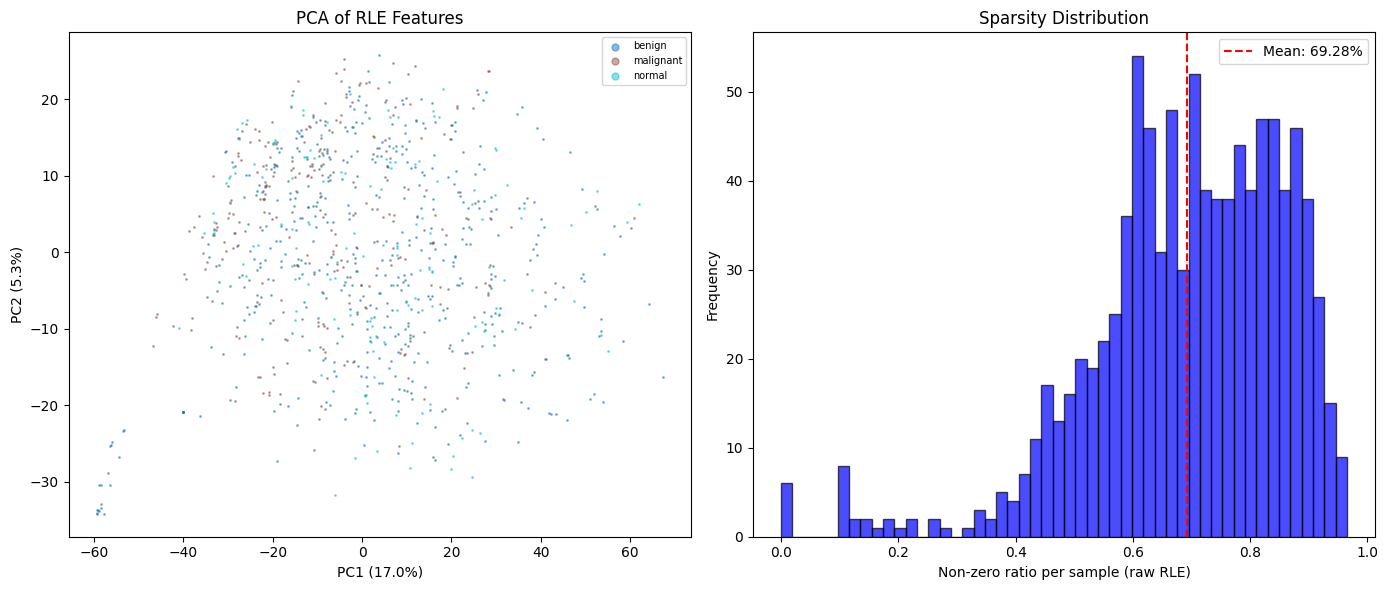


4. FEATURE IMPORTANCE (Top 10 by variance)
--------------------------------------------------
     1. Feature 1380  branch=row  run_pos=0  type=start  var=1.0000
     2. Feature 1344  branch=row  run_pos=0  type=start  var=1.0000
     3. Feature 1368  branch=row  run_pos=0  type=start  var=1.0000
     4. Feature 1464  branch=row  run_pos=0  type=start  var=1.0000
     5. Feature  319  branch=row  run_pos=7  type=length  var=1.0000
     6. Feature  251  branch=row  run_pos=11  type=intensity  var=1.0000
     7. Feature  598  branch=row  run_pos=10  type=length  var=1.0000
     8. Feature  405  branch=row  run_pos=9  type=start  var=1.0000
     9. Feature 1044  branch=row  run_pos=0  type=start  var=1.0000
    10. Feature 1471  branch=row  run_pos=7  type=length  var=1.0000

5. RECONSTRUCTION TEST (first test image)
--------------------------------------------------


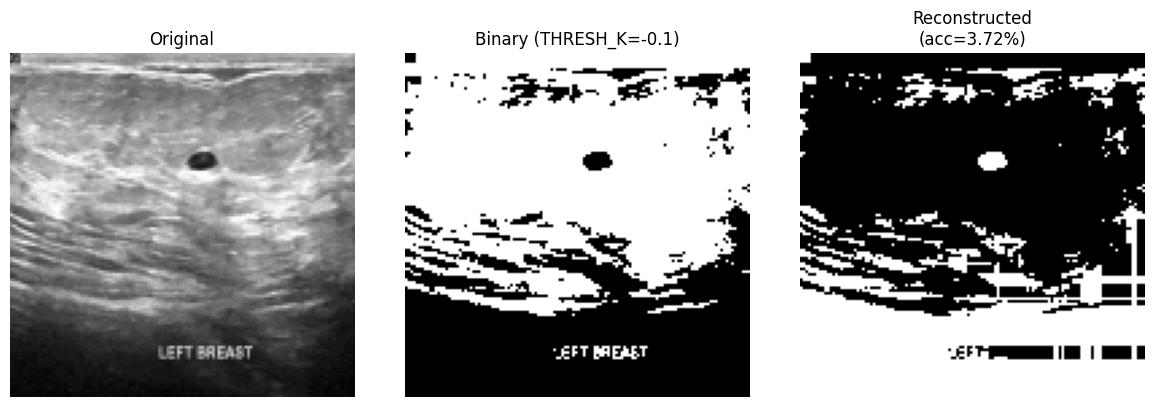

  Threshold              : 126.69  (mean + -0.1*std)
  Reconstruction accuracy: 3.72%
  Feature dim            : 3072

6. CLASS DISTRIBUTION IN FEATURE SPACE
--------------------------------------------------


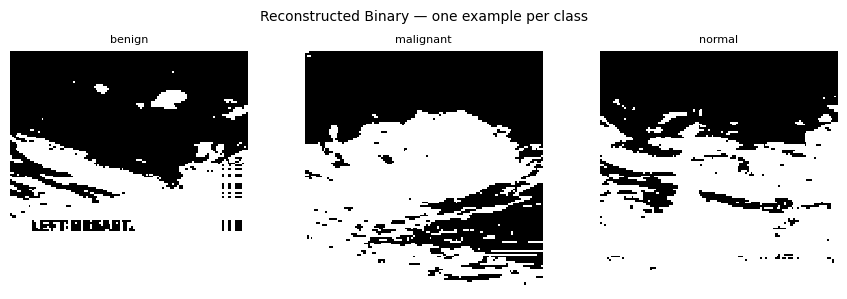


ASSESSMENT SUMMARY
  ✓ Features have meaningful variance
  ✓ Good class separability (B/W > 1.0)
  ✗ Poor reconstruction — check MAX_RUNS
  ✓ Reasonable sparsity (5–80% non-zero)
  ✗ Low PCA variance — features may be noisy

  OVERALL QUALITY : 3/5
  ★ Good.


In [ ]:
# RLE Feature Quality Assessment

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def assess_rle_features(X_train_norm, y_train, X_test_norm, y_test,
                        X_train_raw_feats, X_test_raw_feats,
                        class_names=CLASS_NAMES):

    print("=" * 70)
    print("RLE FEATURE QUALITY ASSESSMENT")
    print("=" * 70)

    # -------------------------------------------------------------------------
    # 1. Basic statistics
    # -------------------------------------------------------------------------
    print("\n1. BASIC STATISTICS")
    print("-" * 50)
    print(f"  Train shape    : {X_train_norm.shape}")
    print(f"  Test shape     : {X_test_norm.shape}")
    print(f"  Feature dtype  : {X_train_norm.dtype}")
    print(f"  Memory (train) : {X_train_norm.nbytes / 1024**2:.2f} MB")

    mean_per_feat = X_train_norm.mean(axis=0)
    std_per_feat  = X_train_norm.std(axis=0)
    min_per_feat  = X_train_norm.min(axis=0)
    max_per_feat  = X_train_norm.max(axis=0)

    print(f"\n  Per-feature statistics (normalized):")
    print(f"    Mean : [{mean_per_feat.min():.4f}, {mean_per_feat.max():.4f}]")
    print(f"    Std  : [{std_per_feat.min():.4f}, {std_per_feat.max():.4f}]")
    print(f"    Min  : [{min_per_feat.min():.4f}, {min_per_feat.max():.4f}]")
    print(f"    Max  : [{max_per_feat.min():.4f}, {max_per_feat.max():.4f}]")

    non_zero_ratio = (X_train_raw_feats > 0.001).mean(axis=1)
    print(f"\n  Sparsity (from raw RLE features):")
    print(f"    Avg non-zero ratio : {non_zero_ratio.mean():.2%}")
    print(f"    Std non-zero ratio : {non_zero_ratio.std():.2%}")
    print(f"    Min non-zero ratio : {non_zero_ratio.min():.2%}")
    print(f"    Max non-zero ratio : {non_zero_ratio.max():.2%}")

    # -------------------------------------------------------------------------
    # 2. Class separability
    # -------------------------------------------------------------------------
    print("\n2. CLASS SEPARABILITY")
    print("-" * 50)

    class_means = []
    for c in range(len(class_names)):
        mask = (y_train == c)
        class_means.append(
            X_train_norm[mask].mean(axis=0) if mask.sum() > 0
            else np.zeros(X_train_norm.shape[1])
        )
    class_means = np.array(class_means)

    global_mean       = X_train_norm.mean(axis=0)
    between_class_var = np.mean([np.linalg.norm(cm - global_mean)**2
                                 for cm in class_means])
    within_class_var  = np.mean([
        np.var(X_train_norm[y_train == c], axis=0).mean()
        for c in range(len(class_names)) if (y_train == c).sum() > 0
    ])
    bw_ratio = between_class_var / (within_class_var + 1e-8)

    print(f"  Between-class variance : {between_class_var:.4f}")
    print(f"  Within-class variance  : {within_class_var:.4f}")
    print(f"  Ratio (B/W)            : {bw_ratio:.2f}")

    print(f"\n  Class mean feature norms:")
    for c, name in enumerate(class_names):
        print(f"    {name:15s}: {np.linalg.norm(class_means[c]):.4f}")

    # -------------------------------------------------------------------------
    # 3. PCA visualization
    # -------------------------------------------------------------------------
    print("\n3. PCA VISUALIZATION")
    print("-" * 50)

    n_samples = min(5000, len(X_train_norm))
    idx       = np.random.choice(len(X_train_norm), n_samples, replace=False)
    X_sample  = X_train_norm[idx]
    y_sample  = y_train[idx]

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    pca      = PCA(n_components=50)
    X_pca    = pca.fit_transform(X_scaled)
    cum_var  = np.cumsum(pca.explained_variance_ratio_)

    print(f"  Explained variance:")
    print(f"    PC1    : {pca.explained_variance_ratio_[0]:.2%}")
    print(f"    PC2    : {pca.explained_variance_ratio_[1]:.2%}")
    print(f"    Top 5  : {cum_var[4]:.2%}")
    print(f"    Top 10 : {cum_var[9]:.2%}")
    print(f"    Top 20 : {cum_var[19]:.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    for c, name in enumerate(class_names):
        m = (y_sample == c)
        axes[0].scatter(X_pca[m, 0], X_pca[m, 1],
                        c=[colors[c]], label=name, alpha=0.5, s=1)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    axes[0].set_title('PCA of RLE Features')
    axes[0].legend(loc='best', fontsize=7, markerscale=5)

    axes[1].hist(non_zero_ratio, bins=50, alpha=0.7,
                 color='blue', edgecolor='black')
    axes[1].set_xlabel('Non-zero ratio per sample (raw RLE)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Sparsity Distribution')
    axes[1].axvline(non_zero_ratio.mean(), color='red', linestyle='--',
                    label=f'Mean: {non_zero_ratio.mean():.2%}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 4. Feature importance
    # -------------------------------------------------------------------------
    print("\n4. FEATURE IMPORTANCE (Top 10 by variance)")
    print("-" * 50)

    feat_variance = X_train_norm.var(axis=0)
    top_features  = np.argsort(feat_variance)[-20:][::-1]
    half          = X_train_norm.shape[1] // 2

    for i, fidx in enumerate(top_features[:10]):
        branch  = "row" if fidx < half else "col"
        local   = fidx if fidx < half else fidx - half
        run_pos = local % (MAX_RUNS * 3)                        # ← was * 2
        feat_type = ["start", "length", "intensity"][run_pos % 3]
        print(f"    {i+1:2d}. Feature {fidx:4d}  branch={branch}  "
              f"run_pos={run_pos}  type={feat_type}  var={feat_variance[fidx]:.4f}")

    # -------------------------------------------------------------------------
    # 5. Reconstruction test
    # -------------------------------------------------------------------------
    print("\n5. RECONSTRUCTION TEST (first test image)")
    print("-" * 50)

    def reconstruct_from_rle(raw_feats, H=CROP_ROWS, W=IMAGE_SIZE,
                              max_runs=MAX_RUNS):
        """Expects RAW un-normalized RLE features — stride is now 3."""
        binary   = np.zeros((H, W), dtype=np.uint8)

        row_feat = raw_feats[:H * max_runs * 3].reshape(H, max_runs * 3)  
        for i in range(H):
            for j in range(max_runs):
                s = int(row_feat[i, j*3]     * W)   
                l = int(row_feat[i, j*3 + 1] * W)   
                if l > 0:
                    binary[i, s:min(s+l, W)] = 1

        # col branch — stride 3
        col_feat = raw_feats[H * max_runs * 3:].reshape(W, max_runs * 3)  
        for j in range(W):
            for k in range(max_runs):
                s = int(col_feat[j, k*3]     * H)   
                l = int(col_feat[j, k*3 + 1] * H)   
                if l > 0:
                    binary[s:min(s+l, H), j] = 1
        return binary

    orig_img = np.array(X_train_raw[0], dtype=np.uint8)
    if orig_img.shape[0] != IMAGE_SIZE or orig_img.shape[1] != IMAGE_SIZE:
        orig_img = cv2.resize(orig_img, (IMAGE_SIZE, IMAGE_SIZE),
                              interpolation=cv2.INTER_AREA)

    img_f       = orig_img.astype(np.float32)
    threshold   = img_f.mean() + THRESH_K * img_f.std()
    binary_orig = (img_f > threshold).astype(np.uint8)

    raw_feat0     = _rle_from_array(orig_img)
    reconstructed = reconstruct_from_rle(raw_feat0)

    recon_acc = (binary_orig == reconstructed).mean()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig_img,      cmap='gray'); axes[0].set_title('Original');                               axes[0].axis('off')
    axes[1].imshow(binary_orig,   cmap='gray'); axes[1].set_title(f'Binary (THRESH_K={THRESH_K})');          axes[1].axis('off')
    axes[2].imshow(reconstructed, cmap='gray'); axes[2].set_title(f'Reconstructed\n(acc={recon_acc:.2%})');  axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    print(f"  Threshold              : {threshold:.2f}  (mean + {THRESH_K}*std)")
    print(f"  Reconstruction accuracy: {recon_acc:.2%}")
    print(f"  Feature dim            : {len(raw_feat0)}")

    # -------------------------------------------------------------------------
    # 6. Class distribution
    # -------------------------------------------------------------------------
    print("\n6. CLASS DISTRIBUTION IN FEATURE SPACE")
    print("-" * 50)

    n_cols = min(5, len(class_names))
    n_rows = (len(class_names) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()

    for c, name in enumerate(class_names):
        class_indices = np.where(y_train == c)[0]
        if len(class_indices) == 0:
            axes[c].axis('off')
            continue
        raw_feat = X_train_raw_feats[class_indices[0]]
        binary   = reconstruct_from_rle(raw_feat)
        axes[c].imshow(binary, cmap='gray', interpolation='nearest')
        axes[c].set_title(name, fontsize=8)
        axes[c].axis('off')

    for i in range(len(class_names), len(axes)):
        axes[i].axis('off')

    plt.suptitle('Reconstructed Binary — one example per class', fontsize=10)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("ASSESSMENT SUMMARY")
    print("=" * 70)

    quality_score = 0
    checks = [
        (feat_variance.mean() > 0.01,         "Features have meaningful variance",
                                               "Low variance — check THRESH_K"),
        (bw_ratio > 1.0,                       "Good class separability (B/W > 1.0)",
                                               "Poor class separability"),
        (recon_acc > 0.7,                      "Good reconstruction (> 70%)",
                                               "Poor reconstruction — check MAX_RUNS"),
        (0.05 < non_zero_ratio.mean() < 0.8,  "Reasonable sparsity (5–80% non-zero)",
                                               f"Unusual sparsity {non_zero_ratio.mean():.2%} — check THRESH_K"),
        (cum_var[9] > 0.5,                     "Top 10 PCs capture > 50% variance",
                                               "Low PCA variance — features may be noisy"),
    ]

    for passed, good_msg, bad_msg in checks:
        if passed:
            print(f"  ✓ {good_msg}"); quality_score += 1
        else:
            print(f"  ✗ {bad_msg}")

    print(f"\n  OVERALL QUALITY : {quality_score}/5")
    if   quality_score >= 4: print("  ★ Excellent!")
    elif quality_score >= 3: print("  ★ Good.")
    elif quality_score >= 2: print("  ⚠  Okay — needs tuning.")
    else:                    print("  ✗  Poor — check THRESH_K and IMAGE_SIZE.")
    print("=" * 70)

    return {
        'quality_score'          : quality_score,
        'reconstruction_accuracy': recon_acc,
        'class_separability'     : bw_ratio,
        'sparsity'               : non_zero_ratio.mean(),
        'pca_explained_top10'    : cum_var[9],
    }


# =============================================================================
# Call
# =============================================================================
results = assess_rle_features(
    X_train_norm      = X_train_n,
    y_train           = y_train,
    X_test_norm       = X_test_n,
    y_test            = y_test,
    X_train_raw_feats = X_train_raw_feats,
    X_test_raw_feats  = X_train_raw_feats,  
)

In [142]:
for cls in range(NUM_CLASSES):
    idx = np.where(y_test == cls)[0][0]
    img = X_train_raw[idx].astype(np.float32)
    mean = img.mean()
    std  = img.std()
    threshold = mean - THRESH_K * std
    binary = (img < threshold).astype(np.uint8)
    print(f"class {cls}  threshold={threshold:.1f}  "
          f"fg_ratio={binary.mean():.2%}  "
          f"mean={mean:.1f}  std={std:.1f}")

class 0  threshold=109.1  fg_ratio=53.86%  mean=103.2  std=58.3
class 1  threshold=138.2  fg_ratio=49.41%  mean=132.4  std=58.4
class 2  threshold=109.9  fg_ratio=48.40%  mean=103.5  std=63.9


In [ ]:
# CELL 8 — Architecture  (dilated×1 → k2s2 → k3s2 → cross-attn → FC)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        log_prob = F.log_softmax(logits, dim=1)
        prob     = log_prob.exp()
        pt       = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        ce       = F.nll_loss(log_prob, targets, reduction="none")
        loss     = ((1.0 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            loss = self.alpha.to(logits.device)[targets] * loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


class RLEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class CrossAttention1D(nn.Module):
    """Row attends to col, col attends to row — gated cross-attention."""
    def __init__(self, dim, bottleneck=32):
        super().__init__()
        self.gate_row = nn.Sequential(
            nn.Linear(dim, bottleneck), nn.ReLU(),
            nn.Linear(bottleneck, dim), nn.Sigmoid())
        self.gate_col = nn.Sequential(
            nn.Linear(dim, bottleneck), nn.ReLU(),
            nn.Linear(bottleneck, dim), nn.Sigmoid())

    def forward(self, row, col):
        row_out = row * self.gate_row(col)
        col_out = col * self.gate_col(row)
        return row_out, col_out


class RLEClassifier(nn.Module):

    def __init__(self,
                 num_classes  = NUM_CLASSES,
                 pool_out     = POOL_OUT,
                 fc_hidden    = FC_HIDDEN,
                 fc_dropout   = FC_DROPOUT,
                 conv_dropout = CONV_DROPOUT):
        super().__init__()

        row_len = CROP_ROWS  * MAX_RUNS * 3
        col_len = IMAGE_SIZE * MAX_RUNS * 3

        def _make_branch(dropout):
            return nn.Sequential(
                nn.Conv1d(1,  32, kernel_size=3, stride=3),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=0),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=0),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            )

        self.conv_row = _make_branch(conv_dropout)
        self.conv_col = _make_branch(conv_dropout)
        self.pool     = nn.AdaptiveAvgPool1d(pool_out)

        branch_dim = 64 * pool_out
        fused_dim  = branch_dim * 2

        self.cross_attn = CrossAttention1D(branch_dim, bottleneck=32)

        self.fc = nn.Sequential(
            nn.Linear(fused_dim, fc_hidden),
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, fc_hidden // 2),
            nn.BatchNorm1d(fc_hidden // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden // 2, num_classes),
        )

        total = sum(p.numel() for p in self.parameters())
        print(f"\n[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC")
        print(f"  row input    : (B, 1, {row_len})")
        print(f"  col input    : (B, 1, {col_len})")
        print(f"  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch")
        print(f"  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch")
        print(f"  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch")
        print(f"  pool_out     : {pool_out}")
        print(f"  branch_dim   : 64 x {pool_out} = {branch_dim}")
        print(f"  cross_attn   : row↔col  bottleneck=32")
        print(f"  fused_dim    : {fused_dim}")
        print(f"  fc_hidden    : {fc_hidden}")
        print(f"  output       : {num_classes} classes")
        print(f"  total params : {total:,}")

    def forward(self, x):
        x_row = x[:, :ROW_FEAT].unsqueeze(1)           # (B, 1, row_len)
        x_col = x[:, ROW_FEAT:].unsqueeze(1)           # (B, 1, col_len)

        y_row = self.pool(self.conv_row(x_row)).flatten(1)  # (B, branch_dim)
        y_col = self.pool(self.conv_col(x_col)).flatten(1)  # (B, branch_dim)

        y_row, y_col = self.cross_attn(y_row, y_col)

        return self.fc(torch.cat([y_row, y_col], dim=1))


_ = RLEClassifier()
print("\n✓ Architecture defined.")


[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC
  row input    : (B, 1, 1536)
  col input    : (B, 1, 1536)
  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch
  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch
  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch
  pool_out     : 2
  branch_dim   : 64 x 2 = 128
  cross_attn   : row↔col  bottleneck=32
  fused_dim    : 256
  fc_hidden    : 128
  output       : 3 classes
  total params : 96,451

✓ Architecture defined.


In [ ]:
# CELL 8.5 — compute_loss_fn  (insert this before Cell 9)

def compute_loss_fn(y: np.ndarray) -> nn.Module:
    """Build the loss function with optional class weighting."""
    if IMBALANCE_STRATEGY == "class_weight":
        classes = np.unique(y)
        weights = compute_class_weight("balanced", classes=classes, y=y)
        
        w = np.ones(NUM_CLASSES, dtype=np.float32)
        for c, wt in zip(classes, weights):
            w[int(c)] = float(wt)
        alpha = torch.tensor(w)
    else:
        alpha = None

    if LOSS_FN == "focal":
        return FocalLoss(alpha=alpha, gamma=FOCAL_GAMMA)
    else:
        return nn.CrossEntropyLoss(weight=alpha)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        # skip .to(DEVICE) — GPUDataset already on GPU
        # but keep it safe for non-GPU loaders
        if X_batch.device.type != 'cuda':
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, scaler):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs_list  = []   
    all_labels_list = []   
    with torch.no_grad():
        for X_batch, y_batch in loader:
            if X_batch.device.type != 'cuda':
                X_batch = X_batch.to(DEVICE, non_blocking=True)
                y_batch = y_batch.to(DEVICE, non_blocking=True)

            if scaler:
                with torch.amp.autocast('cuda'):
                    logits = model(X_batch)
                    loss   = criterion(logits, y_batch)
            else:
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

            probs = torch.softmax(logits.float(), dim=1)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

            # ── keep on GPU until all batches done ────────────────────
            all_probs_list.append(probs)
            all_labels_list.append(y_batch)

    # ── ONE transfer at the end instead of per-batch ──────────────────
    all_probs  = torch.cat(all_probs_list,  dim=0).cpu().numpy().astype(np.float64)
    all_labels = torch.cat(all_labels_list, dim=0).cpu().numpy()

    avg_loss = total_loss / total
    acc      = correct / total

    try:
        auc = roc_auc_score(all_labels, all_probs,
                            multi_class='ovr', average='macro',
                            labels=list(range(NUM_CLASSES)))
    except Exception as e:
        log.warning("AUC failed: %s", e)
        auc = 0.0

    return avg_loss, acc, auc, all_labels, all_probs

In [ ]:
# CELL 8.7 — Fast training — no DataLoader, direct GPU slicing
set_seed(SEED)

# ── pre-load to GPU once ──────────────────────────────────────────────────────
X_train_gpu = torch.from_numpy(X_train_n).to(DEVICE)
y_train_gpu = torch.from_numpy(y_train.astype(np.int64)).to(DEVICE)
X_test_gpu  = torch.from_numpy(X_test_n).to(DEVICE)
y_test_gpu  = torch.from_numpy(y_test.astype(np.int64)).to(DEVICE)

N_train = len(X_train_gpu)
N_test  = len(X_test_gpu)

def train_epoch_fast(model, X, y, optimizer, criterion, scaler, batch_size):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    perm = torch.randperm(len(X), device=DEVICE)
    X, y = X[perm], y[perm]

    for i in range(0, len(X) - batch_size + 1, batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        optimizer.zero_grad(set_to_none=True)

        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate_fast(model, X, y, criterion, scaler, batch_size):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            if scaler:
                with torch.amp.autocast('cuda'):
                    logits = model(X_batch)
                    loss   = criterion(logits, y_batch)
            else:
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

            probs = torch.softmax(logits.float(), dim=1)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
            all_probs.append(probs)
            all_labels.append(y_batch)

    all_probs  = torch.cat(all_probs,  dim=0).cpu().numpy().astype(np.float64)
    all_labels = torch.cat(all_labels, dim=0).cpu().numpy()

    try:
        auc = roc_auc_score(all_labels, all_probs,
                            multi_class='ovr', average='macro',
                            labels=list(range(NUM_CLASSES)))
    except Exception as e:
        auc = 0.0

    return total_loss / total, correct / total, auc, all_labels, all_probs


# ── model init ────────────────────────────────────────────────────────────────
feat_model     = RLEClassifier().to(DEVICE)
feat_criterion = compute_loss_fn(y_train)
feat_optimizer = AdamW(feat_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
feat_scheduler = CosineAnnealingLR(feat_optimizer, T_max=EPOCHS)
feat_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

best_auc, best_state, no_improve = 0.0, None, 0

print("Training feature extraction model...")
print(f"{'Epoch':>5}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_fast(
        feat_model, X_train_gpu, y_train_gpu,
        feat_optimizer, feat_criterion, feat_scaler, BATCH_SIZE)

    va_loss, va_acc, va_auc, _, _ = evaluate_fast(
        feat_model, X_test_gpu, y_test_gpu,
        feat_criterion, feat_scaler, BATCH_SIZE)

    feat_scheduler.step()

    if va_auc > best_auc:
        best_auc   = va_auc
        best_state = {k: v.cpu().clone() for k, v in feat_model.state_dict().items()}
        no_improve = 0
        marker     = " ✓"
    else:
        no_improve += 1
        marker     = ""

    print(f"{epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

    if no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

feat_model.load_state_dict(best_state)
print(f"\nBest AUC: {best_auc:.4f}")

# ── feature extractor ─────────────────────────────────────────────────────────
class FeatureExtractor(nn.Module):
    def __init__(self, rle_model):
        super().__init__()
        self.conv_row   = rle_model.conv_row
        self.conv_col   = rle_model.conv_col
        self.pool       = rle_model.pool
        self.cross_attn = rle_model.cross_attn

    def forward(self, x):
        x_row = x[:, :ROW_FEAT].unsqueeze(1)
        x_col = x[:, ROW_FEAT:].unsqueeze(1)
        y_row = self.pool(self.conv_row(x_row)).flatten(1)
        y_col = self.pool(self.conv_col(x_col)).flatten(1)
        y_row, y_col = self.cross_attn(y_row, y_col)
        return torch.cat([y_row, y_col], dim=1)

extractor = FeatureExtractor(feat_model).to(DEVICE)

# ── batched extraction — avoids OOM on 6GB GPU ───────────────────────────────
def extract_batched(extractor, X_gpu, batch_size=512):
    extractor.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, len(X_gpu), batch_size):
            chunk = extractor(X_gpu[i:i+batch_size])
            chunks.append(chunk.cpu())   
    return torch.cat(chunks, dim=0).numpy()

print("\nExtracting conv features...")
X_train_conv = extract_batched(extractor, X_train_gpu, batch_size=512)
X_test_conv  = extract_batched(extractor, X_test_gpu,  batch_size=512)

print(f"  Train : {X_train_conv.shape}")
print(f"  Test  : {X_test_conv.shape}")
print("✓ Features ready for XGBoost in Cell 10B")


[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC
  row input    : (B, 1, 1536)
  col input    : (B, 1, 1536)
  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch
  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch
  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch
  pool_out     : 2
  branch_dim   : 64 x 2 = 128
  cross_attn   : row↔col  bottleneck=32
  fused_dim    : 256
  fc_hidden    : 128
  output       : 3 classes
  total params : 96,451
Training feature extraction model...
Epoch    TrLoss    TrAcc    VaLoss    VaAcc      AUC
--------------------------------------------------------
    1    0.4568   0.4353    0.4062   0.3875   0.7238 ✓
    2    0.3837   0.5123    0.3954   0.3750   0.7872 ✓
    3    0.3533   0.5670    0.3482   0.4875   0.7937 ✓
    4    0.2976   0.6283    0.3331   0.4938   0.7792
    5    0.3012   0.6105    0.3997   0.5563   0.7864
    6    0.2930   0.6049    0.3266   0.5062   0.7969 ✓
    7    0.2582   0.

In [ ]:
# CELL 8.8 — RLE 5-Fold CV  (RLEClassifier on RLE features, GPU-fast)


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
import numpy as np
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

print("=" * 70)
print("  RLE 5-Fold Stratified CV  (RLEClassifier, GPU-fast batch)")
print("=" * 70)
print(f"  Dataset     : X_train_n  {X_train_n.shape}  |  y_train  {y_train.shape}")
print(f"  Device      : {DEVICE}")
print(f"  BATCH_SIZE  : {BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}")
print(f"  EPOCHS      : {EPOCHS}  PATIENCE={PATIENCE}")
print()

skf_rle = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rle_cv_aucs = []
rle_cv_accs = []
rle_cv_f1s  = []
rle_cv_cms  = []

for fold, (tr_idx, va_idx) in enumerate(skf_rle.split(X_train_n, y_train)):

    set_seed(SEED + fold)   

    print(f"\n{'─'*70}")
    print(f"  FOLD {fold+1}/5   train={len(tr_idx)}  val={len(va_idx)}")
    print(f"{'─'*70}")

    # ── data → GPU ──────────────────────────────────────────────────────────
    X_tr_gpu = torch.from_numpy(X_train_n[tr_idx]).to(DEVICE)
    y_tr_gpu = torch.from_numpy(y_train[tr_idx].astype(np.int64)).to(DEVICE)
    X_va_gpu = torch.from_numpy(X_train_n[va_idx]).to(DEVICE)
    y_va_gpu = torch.from_numpy(y_train[va_idx].astype(np.int64)).to(DEVICE)

    # ── model, loss, optimiser ──────────────────────────────────────────────
    fold_model     = RLEClassifier().to(DEVICE)
    fold_criterion = compute_loss_fn(y_train[tr_idx])
    fold_optimizer = AdamW(fold_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    fold_scheduler = CosineAnnealingLR(fold_optimizer, T_max=EPOCHS)
    fold_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

    best_auc_fold   = 0.0
    best_state_fold = None
    no_imp_fold     = 0

    print(f"  {'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  "
          f"{'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
    print(f"  {'----':>4}  {'--------':>8}  {'-------':>7}  "
          f"{'--------':>8}  {'-------':>7}  {'-------':>7}")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch_fast(
            fold_model, X_tr_gpu, y_tr_gpu,
            fold_optimizer, fold_criterion, fold_scaler, BATCH_SIZE)

        va_loss, va_acc, va_auc, _, _ = evaluate_fast(
            fold_model, X_va_gpu, y_va_gpu,
            fold_criterion, fold_scaler, BATCH_SIZE)

        fold_scheduler.step()

        if va_auc > best_auc_fold:
            best_auc_fold   = va_auc
            best_state_fold = {k: v.cpu().clone()
                               for k, v in fold_model.state_dict().items()}
            no_imp_fold     = 0
            marker          = " ✓"
        else:
            no_imp_fold += 1
            marker       = ""

        print(f"  {epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
              f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

        if no_imp_fold >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    # ── best weights → predict ──────────────────────────────────────────────
    fold_model.load_state_dict(best_state_fold)
    _, va_acc_best, va_auc_best, va_labels, va_probs = evaluate_fast(
        fold_model, X_va_gpu, y_va_gpu,
        fold_criterion, fold_scaler, BATCH_SIZE)

    y_pred_fold = np.argmax(va_probs, axis=1)
    macro_f1    = f1_score(va_labels, y_pred_fold, average="macro", zero_division=0)
    cm_fold     = confusion_matrix(va_labels, y_pred_fold,
                                   labels=list(range(NUM_CLASSES)))

    rle_cv_aucs.append(va_auc_best)
    rle_cv_accs.append(va_acc_best)
    rle_cv_f1s.append(macro_f1)
    rle_cv_cms.append(cm_fold)

    # ── confusion matrix ─────────────────────────────────────────────────────
    print(f"\n  Confusion Matrix — Fold {fold+1}  (rows=True, cols=Pred):")
    header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
    print(f"  {'':>8}{header_cv}")
    for i, row in enumerate(cm_fold):
        vals = "".join(f"  {v:>8}" for v in row)
        print(f"  {CLASS_NAMES[i]:>8}{vals}")

    # ── per-class TP/FP/FN/TN ────────────────────────────────────────────────
    print(f"\n  Per-class metrics — Fold {fold+1}:")
    print(f"  {'Class':<10}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
          f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
    print(f"  {'-'*64}")
    for i, name in enumerate(CLASS_NAMES):
        TP = cm_fold[i, i]
        FP = cm_fold[:, i].sum() - TP
        FN = cm_fold[i, :].sum() - TP
        TN = cm_fold.sum() - TP - FP - FN
        prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0
        print(f"  {name:<10}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
              f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

    print(f"\n  Fold {fold+1} → Best AUC={va_auc_best:.4f}  "
          f"Acc={va_acc_best:.4f}  Macro-F1={macro_f1:.4f}")

    # ── free GPU memory before next fold ─────────────────────────────────────
    del fold_model, X_tr_gpu, y_tr_gpu, X_va_gpu, y_va_gpu
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# ── aggregate ─────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  RLE 5-Fold CV — Aggregate Results")
print(f"{'='*70}")
print(f"  {'Fold':<6}  {'AUC':>8}  {'Accuracy':>10}  {'Macro-F1':>10}")
print(f"  {'-'*40}")
for i, (a, ac, f) in enumerate(zip(rle_cv_aucs, rle_cv_accs, rle_cv_f1s)):
    print(f"  {i+1:<6}  {a:>8.4f}  {ac:>10.4f}  {f:>10.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<6}  {np.mean(rle_cv_aucs):>8.4f}  "
      f"{np.mean(rle_cv_accs):>10.4f}  {np.mean(rle_cv_f1s):>10.4f}")
print(f"  {'Std':<6}  {np.std(rle_cv_aucs):>8.4f}  "
      f"{np.std(rle_cv_accs):>10.4f}  {np.std(rle_cv_f1s):>10.4f}")
print(f"{'='*70}")

# ── mean confusion matrix ─────────────────────────────────────────────────────
mean_cm_rle = np.mean(rle_cv_cms, axis=0)
print(f"\n  Mean Confusion Matrix (averaged over 5 folds):")
header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
print(f"  {'':>8}{header_cv}")
for i, row in enumerate(mean_cm_rle):
    vals = "".join(f"  {v:>8.1f}" for v in row)
    print(f"  {CLASS_NAMES[i]:>8}{vals}")

print(f"\n✓ rle_cv_aucs / rle_cv_accs / rle_cv_f1s stored for comparison")

  RLE 5-Fold Stratified CV  (RLEClassifier, GPU-fast batch)
  Dataset     : X_train_n  (956, 3072)  |  y_train  (956,)
  Device      : cuda
  BATCH_SIZE  : 64  LR=0.006  WD=0.005
  EPOCHS      : 100  PATIENCE=30


──────────────────────────────────────────────────────────────────────
  FOLD 1/5   train=764  val=192
──────────────────────────────────────────────────────────────────────

[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC
  row input    : (B, 1, 1536)
  col input    : (B, 1, 1536)
  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch
  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch
  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch
  pool_out     : 2
  branch_dim   : 64 x 2 = 128
  cross_attn   : row↔col  bottleneck=32
  fused_dim    : 256
  fc_hidden    : 128
  output       : 3 classes
  total params : 96,451
    Ep    TrLoss    TrAcc    VaLoss    VaAcc      AUC
  ----  --------  -------  --------  -------  -----

In [149]:
# CELL 10B — XGBoost on Conv1D extracted features


import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

# ── 1. extract features from trained conv branches ──────────────────────────

class FeatureExtractor(nn.Module):
    """Strips the FC head — returns fused (B, 256) conv features."""
    def __init__(self, rle_model):
        super().__init__()
        self.conv_row   = rle_model.conv_row
        self.conv_col   = rle_model.conv_col
        self.pool       = rle_model.pool
        self.cross_attn = rle_model.cross_attn

    def forward(self, x):
        x_row = x[:, :ROW_FEAT].unsqueeze(1)
        x_col = x[:, ROW_FEAT:].unsqueeze(1)
        y_row = self.pool(self.conv_row(x_row)).flatten(1)
        y_col = self.pool(self.conv_col(x_col)).flatten(1)
        y_row, y_col = self.cross_attn(y_row, y_col)
        return torch.cat([y_row, y_col], dim=1)   # (B, 256)


def extract_features(extractor, X, batch_size=64):
    extractor.eval()
    dataset = RLEDataset(X, np.zeros(len(X), dtype=np.int64))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    feats   = []
    with torch.no_grad():
        for xb, _ in loader:
            feats.append(extractor(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(feats, axis=0)


# use the model trained in Cell 9 (best state already loaded)
# use the model trained in Cell 8.7
extractor = FeatureExtractor(feat_model).to(DEVICE)

print("Extracting conv features...")
X_train_conv = extract_features(extractor, X_train_n)
X_test_conv  = extract_features(extractor, X_test_n)
print(f"  Train features : {X_train_conv.shape}")
print(f"  Test  features : {X_test_conv.shape}")

# ── 2. train XGBoost ─────────────────────────────────────────────────────────

xgb_model = xgb.XGBClassifier(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    
    eval_metric       = 'mlogloss',
    random_state      = SEED,
    n_jobs            = -1,
)

print("\nTraining XGBoost on conv features...")
xgb_model.fit(X_train_conv, y_train)

# ── 3. evaluate ──────────────────────────────────────────────────────────────

y_prob_xgb = xgb_model.predict_proba(X_test_conv)
y_pred_xgb = np.argmax(y_prob_xgb, axis=1)

auc_xgb  = roc_auc_score(y_test, y_prob_xgb,
                          multi_class='ovr', average='macro',
                          labels=list(range(NUM_CLASSES)))
f1_xgb   = f1_score(y_test, y_pred_xgb, average='macro')
acc_xgb  = (y_pred_xgb == y_test).mean()
cm_xgb   = confusion_matrix(y_test, y_pred_xgb, labels=list(range(NUM_CLASSES)))

print(f"\n=== Conv Features + XGBoost  (AUC={auc_xgb:.4f}  macro-F1={f1_xgb:.4f}) ===\n")
print(classification_report(y_test, y_pred_xgb,
                             target_names=CLASS_NAMES,
                             labels=list(range(NUM_CLASSES))))

print("Confusion matrix (rows=true, cols=pred):")
header = "".join(f"{n:>14}" for n in CLASS_NAMES)
print(f"  {'':16}{header}")
for i, row in enumerate(cm_xgb):
    print(f"  {CLASS_NAMES[i]:<16}" + "".join(f"{v:>14}" for v in row))

print(f"\nROC-AUC (macro OvR) : {auc_xgb:.4f}")
print(f"Macro F1            : {f1_xgb:.4f}")
print(f"Accuracy            : {acc_xgb:.4f}")

Extracting conv features...
  Train features : (956, 256)
  Test  features : (160, 256)

Training XGBoost on conv features...

=== Conv Features + XGBoost  (AUC=0.8642  macro-F1=0.7203) ===

              precision    recall  f1-score   support

      benign       0.77      0.89      0.83        91
   malignant       0.83      0.71      0.77        42
      normal       0.68      0.48      0.57        27

    accuracy                           0.78       160
   macro avg       0.76      0.70      0.72       160
weighted avg       0.77      0.78      0.77       160

Confusion matrix (rows=true, cols=pred):
                          benign     malignant        normal
  benign                      81             5             5
  malignant                   11            30             1
  normal                      13             1            13

ROC-AUC (macro OvR) : 0.8642
Macro F1            : 0.7203
Accuracy            : 0.7750


In [ ]:
# CELL 10C — XGBoost 5-Fold CV on Conv1D Features


import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, accuracy_score
)
import numpy as np
_CLASS_NAMES_DISPLAY = ['benign', 'malignant', 'normal']
# ── XGBoost hyperparameters ──────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators          = 1300,
    max_depth             = 4,
    learning_rate         = 0.1,
    subsample             = 0.8,
    colsample_bytree      = 0.4,
    min_child_weight      = 0,
    gamma                 = 0,
    reg_alpha             = 0,
    reg_lambda            = 1,
    eval_metric           = ["mlogloss", "merror"],  
    early_stopping_rounds = 50,
    random_state          = SEED,
    n_jobs                = -1,
)

print("=" * 70)
print("  XGBoost 5-Fold CV on Conv1D Extracted Features")
print("=" * 70)
print("\n  XGBoost Parameters:")
for k, v in XGB_PARAMS.items():
    print(f"    {k:<26} = {v}")
print(f"    {'objective':<26} = multi:softprob  (auto for n_classes>2)")
print(f"    {'num_class':<26} = {NUM_CLASSES}")
print()

# ── use conv features ────────────────────────────────────────────────────────
X_cv = np.concatenate([X_train_conv, X_test_conv], axis=0)
y_cv = np.concatenate([y_train,      y_test],       axis=0)

print(f"  Total samples for CV : {len(X_cv)}  (train {len(X_train_conv)} + test {len(X_test_conv)})")
print(f"  Feature dimension    : {X_cv.shape[1]}")
print(f"  Class distribution   :")
for c, name in enumerate(_CLASS_NAMES_DISPLAY):
    print(f"    {name}: {(y_cv == c).sum()}")
print()

# ── 5-fold StratifiedKFold ───────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_aucs = []
fold_accs = []
fold_f1s  = []
fold_cms  = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv)):
    X_tr, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_va, y_va = X_cv[va_idx], y_cv[va_idx]

    print(f"\n{'─'*90}")
    print(f"  FOLD {fold+1}/5   train={len(tr_idx)}  val={len(va_idx)}")
    print(f"{'─'*90}")

    from sklearn.utils.class_weight import compute_sample_weight
    sample_weights = compute_sample_weight("balanced", y=y_tr)

    xgb_fold = xgb.XGBClassifier(**XGB_PARAMS)
    xgb_fold.fit(
        X_tr, y_tr,
        sample_weight = sample_weights,
        eval_set      = [(X_tr, y_tr), (X_va, y_va)],
        verbose       = False,
    )

    results   = xgb_fold.evals_result()
    tr_loss   = results["validation_0"]["mlogloss"]
    va_loss   = results["validation_1"]["mlogloss"]
    tr_err    = results["validation_0"]["merror"]  
    va_err    = results["validation_1"]["merror"]

    best_idx  = int(np.argmin(va_loss))

    # ── epoch log ────────────────────────────────────────────────────────────
    print(f"\n  Epoch log (every 10 rounds):")
    print(f"  {'Round':>6}  "
          f"{'tr-loss':>10}  {'val-loss':>10}  "
          f"{'tr-acc':>8}  {'val-acc':>8}  "
          f"{'tr-err':>8}  {'val-err':>8}")
    print(f"  {'------':>6}  "
          f"{'----------':>10}  {'----------':>10}  "
          f"{'--------':>8}  {'--------':>8}  "
          f"{'--------':>8}  {'--------':>8}")

    for rnd in range(9, len(tr_loss), 10):
        marker   = "  ← best" if rnd == best_idx else ""
        tr_acc_r = 1.0 - tr_err[rnd]
        va_acc_r = 1.0 - va_err[rnd]
        print(f"  {rnd+1:>6}  "
              f"{tr_loss[rnd]:>10.5f}  {va_loss[rnd]:>10.5f}  "
              f"{tr_acc_r:>8.4f}  {va_acc_r:>8.4f}  "
              f"{tr_err[rnd]:>8.4f}  {va_err[rnd]:>8.4f}"
              f"{marker}")

    # always show best round if not already shown
    if best_idx % 10 != 9:
        tr_acc_b = 1.0 - tr_err[best_idx]
        va_acc_b = 1.0 - va_err[best_idx]
        print(f"  {best_idx+1:>6}  "
              f"{tr_loss[best_idx]:>10.5f}  {va_loss[best_idx]:>10.5f}  "
              f"{tr_acc_b:>8.4f}  {va_acc_b:>8.4f}  "
              f"{tr_err[best_idx]:>8.4f}  {va_err[best_idx]:>8.4f}"
              f"  ← best")

    print(f"\n  Early stop / best round : {best_idx+1}"
          f"  |  Best val-loss : {va_loss[best_idx]:.5f}"
          f"  |  Best val-acc  : {1.0 - va_err[best_idx]:.4f}")

    # ── predict & full metrics ────────────────────────────────────────────────
    y_prob = xgb_fold.predict_proba(X_va)
    y_pred = np.argmax(y_prob, axis=1)

    try:
        auc = roc_auc_score(y_va, y_prob,
                            multi_class="ovr", average="macro",
                            labels=list(range(NUM_CLASSES)))
    except Exception as e:
        print(f"  AUC warning: {e}")
        auc = 0.0

    acc      = accuracy_score(y_va, y_pred)
    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)
    cm       = confusion_matrix(y_va, y_pred, labels=list(range(NUM_CLASSES)))

    fold_aucs.append(auc)
    fold_accs.append(acc)
    fold_f1s.append(macro_f1)
    fold_cms.append(cm)

    # ── confusion matrix ──────────────────────────────────────────────────────
    print(f"\n  Confusion Matrix — Fold {fold+1}  (rows=True, cols=Pred):")
    header_str = "".join(f"  {n:>12}" for n in _CLASS_NAMES_DISPLAY)
    print(f"  {'':>12}{header_str}")
    for i, row in enumerate(cm):
        vals = "".join(f"  {v:>12}" for v in row)
        print(f"  {_CLASS_NAMES_DISPLAY[i]:>12}{vals}")

    # ── per-class metrics ─────────────────────────────────────────────────────
    print(f"\n  Per-class metrics — Fold {fold+1}:")
    print(f"  {'Class':<14}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
          f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
    print(f"  {'-'*70}")
    for i, name in enumerate(_CLASS_NAMES_DISPLAY):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - TP - FP - FN
        prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = 2*prec*recall / (prec+recall) if (prec+recall) > 0 else 0.0
        print(f"  {name:<14}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
              f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

    print(f"\n  Fold {fold+1} Summary → "
          f"AUC={auc:.4f}  Acc={acc:.4f}  Macro-F1={macro_f1:.4f}")

# ── aggregate results ─────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  XGBoost 5-Fold CV — Aggregate Results")
print(f"{'='*70}")
print(f"  {'Fold':<6}  {'AUC':>8}  {'Accuracy':>10}  {'Macro-F1':>10}")
print(f"  {'-'*40}")
for i, (a, ac, f) in enumerate(zip(fold_aucs, fold_accs, fold_f1s)):
    print(f"  {i+1:<6}  {a:>8.4f}  {ac:>10.4f}  {f:>10.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<6}  {np.mean(fold_aucs):>8.4f}  "
      f"{np.mean(fold_accs):>10.4f}  {np.mean(fold_f1s):>10.4f}")
print(f"  {'Std':<6}  {np.std(fold_aucs):>8.4f}  "
      f"{np.std(fold_accs):>10.4f}  {np.std(fold_f1s):>10.4f}")
print(f"{'='*70}")

# ── mean confusion matrix ─────────────────────────────────────────────────────
mean_cm = np.mean(fold_cms, axis=0)
print(f"\n  Mean Confusion Matrix (averaged over 5 folds):")
header_str = "".join(f"  {n:>12}" for n in _CLASS_NAMES_DISPLAY)
print(f"  {'':>12}{header_str}")
for i, row in enumerate(mean_cm):
    vals = "".join(f"  {v:>12.1f}" for v in row)
    print(f"  {_CLASS_NAMES_DISPLAY[i]:>12}{vals}")

# ── final model on full train ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Final XGBoost: train on X_train_conv → eval on X_test_conv")
print(f"{'='*70}")

sample_weights_full = compute_sample_weight("balanced", y=y_train)

xgb_final = xgb.XGBClassifier(**XGB_PARAMS)
xgb_final.fit(
    X_train_conv, y_train,
    sample_weight = sample_weights_full,
    eval_set      = [(X_train_conv, y_train), (X_test_conv, y_test)],
    verbose       = False,
)

results_final = xgb_final.evals_result()
tr_loss_f     = results_final["validation_0"]["mlogloss"]
va_loss_f     = results_final["validation_1"]["mlogloss"]
tr_err_f      = results_final["validation_0"]["merror"]
va_err_f      = results_final["validation_1"]["merror"]
best_idx_f    = int(np.argmin(va_loss_f))

print(f"\n  Epoch log (every 10 rounds):")
print(f"  {'Round':>6}  "
      f"{'tr-loss':>10}  {'val-loss':>10}  "
      f"{'tr-acc':>8}  {'val-acc':>8}  "
      f"{'tr-err':>8}  {'val-err':>8}")
print(f"  {'------':>6}  "
      f"{'----------':>10}  {'----------':>10}  "
      f"{'--------':>8}  {'--------':>8}  "
      f"{'--------':>8}  {'--------':>8}")

for rnd in range(9, len(tr_loss_f), 10):
    marker   = "  ← best" if rnd == best_idx_f else ""
    tr_acc_r = 1.0 - tr_err_f[rnd]
    va_acc_r = 1.0 - va_err_f[rnd]
    print(f"  {rnd+1:>6}  "
          f"{tr_loss_f[rnd]:>10.5f}  {va_loss_f[rnd]:>10.5f}  "
          f"{tr_acc_r:>8.4f}  {va_acc_r:>8.4f}  "
          f"{tr_err_f[rnd]:>8.4f}  {va_err_f[rnd]:>8.4f}"
          f"{marker}")

if best_idx_f % 10 != 9:
    tr_acc_b = 1.0 - tr_err_f[best_idx_f]
    va_acc_b = 1.0 - va_err_f[best_idx_f]
    print(f"  {best_idx_f+1:>6}  "
          f"{tr_loss_f[best_idx_f]:>10.5f}  {va_loss_f[best_idx_f]:>10.5f}  "
          f"{tr_acc_b:>8.4f}  {va_acc_b:>8.4f}  "
          f"{tr_err_f[best_idx_f]:>8.4f}  {va_err_f[best_idx_f]:>8.4f}"
          f"  ← best")

print(f"\n  Early stop / best round : {best_idx_f+1}"
      f"  |  Best test-loss : {va_loss_f[best_idx_f]:.5f}"
      f"  |  Best test-acc  : {1.0 - va_err_f[best_idx_f]:.4f}")

# ── final predictions ─────────────────────────────────────────────────────────
y_prob_final = xgb_final.predict_proba(X_test_conv)
y_pred_final = np.argmax(y_prob_final, axis=1)

auc_final = roc_auc_score(y_test, y_prob_final,
                           multi_class="ovr", average="macro",
                           labels=list(range(NUM_CLASSES)))
acc_final = accuracy_score(y_test, y_pred_final)
f1_final  = f1_score(y_test, y_pred_final, average="macro", zero_division=0)
cm_final  = confusion_matrix(y_test, y_pred_final, labels=list(range(NUM_CLASSES)))

print(f"\n  Classification Report (held-out test set):")
print(classification_report(y_test, y_pred_final,
                             target_names=_CLASS_NAMES_DISPLAY,
                             labels=list(range(NUM_CLASSES)),
                             zero_division=0))

print(f"  Final Confusion Matrix (rows=True, cols=Pred):")
header_str = "".join(f"  {n:>12}" for n in _CLASS_NAMES_DISPLAY)
print(f"  {'':>12}{header_str}")
for i, row in enumerate(cm_final):
    vals = "".join(f"  {v:>12}" for v in row)
    print(f"  {_CLASS_NAMES_DISPLAY[i]:>12}{vals}")

print(f"\n  Final per-class metrics:")
print(f"  {'Class':<14}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
      f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
print(f"  {'-'*70}")
for i, name in enumerate(_CLASS_NAMES_DISPLAY):
    TP = cm_final[i, i]
    FP = cm_final[:, i].sum() - TP
    FN = cm_final[i, :].sum() - TP
    TN = cm_final.sum() - TP - FP - FN
    prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_c   = 2*prec*recall / (prec+recall) if (prec+recall) > 0 else 0.0
    print(f"  {name:<14}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
          f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

print(f"\n  ROC-AUC (macro OvR) : {auc_final:.4f}")
print(f"  Accuracy            : {acc_final:.4f}")
print(f"  Macro F1            : {f1_final:.4f}")

xgb_cv_result = dict(
    acc  = acc_final,
    auc  = auc_final,
    f1   = f1_final,
    time = 0.0,
)
print(f"\n✓ xgb_cv_result stored → add to Cell 12 all_results dict")

  XGBoost 5-Fold CV on Conv1D Extracted Features

  XGBoost Parameters:
    n_estimators               = 1300
    max_depth                  = 4
    learning_rate              = 0.1
    subsample                  = 0.8
    colsample_bytree           = 0.4
    min_child_weight           = 0
    gamma                      = 0
    reg_alpha                  = 0
    reg_lambda                 = 1
    eval_metric                = ['mlogloss', 'merror']
    early_stopping_rounds      = 50
    random_state               = 42
    n_jobs                     = -1
    objective                  = multi:softprob  (auto for n_classes>2)
    num_class                  = 3

  Total samples for CV : 1116  (train 956 + test 160)
  Feature dimension    : 256
  Class distribution   :
    benign: 632
    malignant: 305
    normal: 179


──────────────────────────────────────────────────────────────────────────────────────────
  FOLD 1/5   train=892  val=224
────────────────────────────────────────────────

In [ ]:
# CELL 8B — FairCNNBaseline  (fast: stride-2 early, ~150K params)

class FairCNNBaseline(nn.Module):
   

    def __init__(self,
                 num_classes  = NUM_CLASSES,
                 fc_hidden    = FC_HIDDEN,
                 fc_dropout   = FC_DROPOUT,
                 conv_dropout = CONV_DROPOUT):
        super().__init__()

        self.features = nn.Sequential(
            # stride=2 → kills 128×128 to 64×64 immediately (cheap)
            nn.Conv2d(1,  32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            # stride=2 → 64×64 to 32×32
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            # all remaining convs on small 32×32 maps — fast
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))  # → (B,64,2,2)
        fused_dim = 64 * 2 * 2                     # 256 — same as RLE

        self.fc = nn.Sequential(
            nn.Linear(fused_dim, fc_hidden),        # 256→128
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, fc_hidden // 2),   # 128→64
            nn.BatchNorm1d(fc_hidden // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden // 2, num_classes), # 64→4
        )

        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n[FairCNNBaseline]  128×128 — stride-2 early, no attention")
        print(f"  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early")
        print(f"  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again")
        print(f"  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops")
        print(f"  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)")
        print(f"  fused_dim : {fused_dim}  ← same as RLE")
        print(f"  fc     : {fused_dim}→{fc_hidden}→{fc_hidden//2}→{num_classes}  ← same as RLE")
        print(f"  total params : {total:,}")
        print(f"  trainable    : {trainable:,}")

    def forward(self, x):
        out = self.pool(self.features(x)).flatten(1)  # (B,256)
        return self.fc(out)


class CNNDataset(Dataset):
    """Serves (1, IMAGE_SIZE, IMAGE_SIZE) float32 tensors in [0,1]."""
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        processed = []
        for img in images:
            if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE),
                                 interpolation=cv2.INTER_AREA)
            processed.append(img.astype(np.float32) / 255.0)
        X = np.stack(processed)
        self.X = torch.from_numpy(X[:, None, :, :])
        self.y = torch.from_numpy(labels.astype(np.int64))

    def __len__(self):           return len(self.X)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]


_ = FairCNNBaseline()
print("\n✓ FairCNNBaseline defined.")


[FairCNNBaseline]  128×128 — stride-2 early, no attention
  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early
  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again
  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops
  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)
  fused_dim : 256  ← same as RLE
  fc     : 256→128→64→3  ← same as RLE
  total params : 171,619
  trainable    : 171,619

✓ FairCNNBaseline defined.


In [ ]:
# CELL 9B — Train FairCNNBaseline  (GPU-preloaded, fast like RLE Cell 8.7)

set_seed(SEED)

def preload_cnn_to_gpu(images, labels):
    """Resize all images once, stack, normalise, push to GPU."""
    processed = []
    for img in images:
        img = np.array(img, dtype=np.uint8)
        if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE),
                             interpolation=cv2.INTER_AREA)
        processed.append(img.astype(np.float32) / 255.0)
    X = np.stack(processed)[:, None, :, :]        # (N,1,128,128)
    X_gpu = torch.from_numpy(X).to(DEVICE)
    y_gpu = torch.from_numpy(labels.astype(np.int64)).to(DEVICE)
    return X_gpu, y_gpu

print("Preloading CNN images to GPU...")
X_cnn_train_gpu, y_cnn_train_gpu = preload_cnn_to_gpu(X_train_raw[idx_tr],  y_train_raw[idx_tr])
X_cnn_test_gpu,  y_cnn_test_gpu  = preload_cnn_to_gpu(X_train_raw[idx_te],  y_train_raw[idx_te])
print(f"  Train : {X_cnn_train_gpu.shape}  Test : {X_cnn_test_gpu.shape}")

# ── model init ────────────────────────────────────────────────────────────────
set_seed(SEED)
cnn_model     = FairCNNBaseline().to(DEVICE)
cnn_criterion = compute_loss_fn(y_train_raw[idx_tr])
cnn_optimizer = AdamW(cnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
cnn_scheduler = CosineAnnealingLR(cnn_optimizer, T_max=EPOCHS)
cnn_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

best_cnn_auc, best_cnn_state = 0.0, None
best_cnn_epoch, cnn_no_improve = 0, 0
t0_cnn = time.time()

print(f"Training FairCNNBaseline on {DEVICE}")
print(f"  BATCH={BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")
print(f"  AMP={'on' if cnn_scaler else 'off'}")
print(f"  train samples : {len(X_cnn_train_gpu)}")
print(f"{'Epoch':>5}  {'TrLoss':>8}  {'TrAcc':>7}  {'TeLoss':>8}  {'TeAcc':>7}  {'AUC':>7}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_fast(
        cnn_model, X_cnn_train_gpu, y_cnn_train_gpu,
        cnn_optimizer, cnn_criterion, cnn_scaler, BATCH_SIZE)

    te_loss, te_acc, te_auc, _, _ = evaluate_fast(
        cnn_model, X_cnn_test_gpu, y_cnn_test_gpu,
        cnn_criterion, cnn_scaler, BATCH_SIZE)

    cnn_scheduler.step()

    if te_auc > best_cnn_auc:
        best_cnn_auc   = te_auc
        best_cnn_epoch = epoch
        cnn_no_improve = 0
        best_cnn_state = {k: v.cpu().clone()
                          for k, v in cnn_model.state_dict().items()}
        marker = " ✓"
    else:
        cnn_no_improve += 1
        marker = ""

    print(f"{epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{te_loss:>8.4f}  {te_acc:>7.4f}  {te_auc:>7.4f}{marker}")

    if cnn_no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

cnn_model.load_state_dict(best_cnn_state)
cnn_time = time.time() - t0_cnn

_, cnn_acc, cnn_auc, cnn_labels, cnn_probs = evaluate_fast(
    cnn_model, X_cnn_test_gpu, y_cnn_test_gpu,
    cnn_criterion, cnn_scaler, BATCH_SIZE)
cnn_f1 = f1_score(cnn_labels, np.argmax(cnn_probs, axis=1),
                  average="macro", zero_division=0)

print(f"\nBest epoch  : {best_cnn_epoch}")
print(f"AUC         : {cnn_auc:.4f}")
print(f"Accuracy    : {cnn_acc:.4f}")
print(f"Macro-F1    : {cnn_f1:.4f}")
print(f"Time        : {cnn_time:.1f}s")

cnn_result = dict(acc=cnn_acc, auc=cnn_auc, f1=cnn_f1, time=cnn_time)
print(f"\n✓ cnn_result stored → add to Cell 12 all_results dict")

Preloading CNN images to GPU...
  Train : torch.Size([638, 1, 128, 128])  Test : torch.Size([160, 1, 128, 128])

[FairCNNBaseline]  128×128 — stride-2 early, no attention
  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early
  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again
  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops
  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)
  fused_dim : 256  ← same as RLE
  fc     : 256→128→64→3  ← same as RLE
  total params : 171,619
  trainable    : 171,619
Training FairCNNBaseline on cuda
  BATCH=64  LR=0.006  WD=0.005  EPOCHS=100  PATIENCE=30
  AMP=on
  train samples : 638
Epoch    TrLoss    TrAcc    TeLoss    TeAcc      AUC
--------------------------------------------------------
    1    0.6061   0.3403    0.5010   0.1938   0.5473 ✓
    2    0.4863   0.4010    0.5126   0.2437   0.5659 ✓
    3    0.4799   0.3958    0.4843   0.3500   0.6341 ✓
    4    0.4549   0.3802    0.4684   0.4750   0.6706 ✓
    5    0.4659   0.4080    0.457

In [ ]:
# CELL 9C — FairCNN 5-Fold Stratified CV  (mirrors Cell 8.8 RLE CV exactly)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
import numpy as np
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

print("=" * 70)
print("  FairCNN 5-Fold Stratified CV  (128×128 raw pixels, DataLoader)")
print("=" * 70)
print(f"  Dataset     : X_train_raw  {X_train_raw.shape}  |  y_train_raw  {y_train_raw.shape}")
print(f"  Device      : {DEVICE}")
print(f"  BATCH_SIZE  : {BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}")
print(f"  EPOCHS      : {EPOCHS}  PATIENCE={PATIENCE}")
print()

skf_cnn = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cnn_cv_aucs = []
cnn_cv_accs = []
cnn_cv_f1s  = []
cnn_cv_cms  = []

pin = (DEVICE.type == "cuda")

for fold, (tr_idx, va_idx) in enumerate(skf_cnn.split(X_train_raw, y_train_raw)):

    set_seed(SEED + fold)

    print(f"\n{'─'*70}")
    print(f"  FOLD {fold+1}/5   train={len(tr_idx)}  val={len(va_idx)}")
    print(f"{'─'*70}")

    fold_train_loader = DataLoader(
        CNNDataset(X_train_raw[tr_idx], y_train_raw[tr_idx]),
        batch_size  = BATCH_SIZE,
        shuffle     = True,
        num_workers = NUM_DATALOADER_WORKERS,
        pin_memory  = pin,
    )
    fold_val_loader = DataLoader(
        CNNDataset(X_train_raw[va_idx], y_train_raw[va_idx]),
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        num_workers = NUM_DATALOADER_WORKERS,
        pin_memory  = pin,
    )

    # ── FIX 1: use fold_model consistently ───────────────────────────────────
    fold_model     = FairCNNBaseline().to(DEVICE)
    fold_criterion = compute_loss_fn(y_train_raw[tr_idx])
    fold_optimizer = AdamW(fold_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    fold_scheduler = CosineAnnealingLR(fold_optimizer, T_max=EPOCHS)
    fold_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

    best_auc_fold   = 0.0
    best_state_fold = None
    no_imp_fold     = 0

    print(f"  {'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  "
          f"{'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
    print(f"  {'----':>4}  {'--------':>8}  {'-------':>7}  "
          f"{'--------':>8}  {'-------':>7}  {'-------':>7}")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(
            fold_model, fold_train_loader,
            fold_optimizer, fold_criterion, fold_scaler)

        va_loss, va_acc, va_auc, _, _ = evaluate(
            fold_model, fold_val_loader,
            fold_criterion, fold_scaler)

        fold_scheduler.step()

        if va_auc > best_auc_fold:
            best_auc_fold   = va_auc
            best_state_fold = {k: v.cpu().clone()
                               for k, v in fold_model.state_dict().items()}
            no_imp_fold     = 0
            marker          = " ✓"
        else:
            no_imp_fold += 1
            marker       = ""

        print(f"  {epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
              f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

        if no_imp_fold >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    fold_model.load_state_dict(best_state_fold)
    _, va_acc_best, va_auc_best, va_labels, va_probs = evaluate(
        fold_model, fold_val_loader, fold_criterion, fold_scaler)

    y_pred_fold = np.argmax(va_probs, axis=1)
    macro_f1    = f1_score(va_labels, y_pred_fold, average="macro", zero_division=0)
    cm_fold     = confusion_matrix(va_labels, y_pred_fold,
                                   labels=list(range(NUM_CLASSES)))

    cnn_cv_aucs.append(va_auc_best)
    cnn_cv_accs.append(va_acc_best)
    cnn_cv_f1s.append(macro_f1)
    cnn_cv_cms.append(cm_fold)

    print(f"\n  Confusion Matrix — Fold {fold+1}  (rows=True, cols=Pred):")
    header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
    print(f"  {'':>8}{header_cv}")
    for i, row in enumerate(cm_fold):
        vals = "".join(f"  {v:>8}" for v in row)
        print(f"  {CLASS_NAMES[i]:>8}{vals}")

    print(f"\n  Per-class metrics — Fold {fold+1}:")
    print(f"  {'Class':<10}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
          f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
    print(f"  {'-'*64}")
    for i, name in enumerate(CLASS_NAMES):
        TP = cm_fold[i, i]
        FP = cm_fold[:, i].sum() - TP
        FN = cm_fold[i, :].sum() - TP
        TN = cm_fold.sum() - TP - FP - FN
        prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0
        print(f"  {name:<10}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
              f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

    print(f"\n  Fold {fold+1} → Best AUC={va_auc_best:.4f}  "
          f"Acc={va_acc_best:.4f}  Macro-F1={macro_f1:.4f}")

    # ── FIX 2: del fold_model (not cnn_model) ────────────────────────────────
    del fold_model, fold_train_loader, fold_val_loader
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# ── aggregate ─────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  FairCNN 5-Fold CV — Aggregate Results")
print(f"{'='*70}")
print(f"  {'Fold':<6}  {'AUC':>8}  {'Accuracy':>10}  {'Macro-F1':>10}")
print(f"  {'-'*40}")
for i, (a, ac, f) in enumerate(zip(cnn_cv_aucs, cnn_cv_accs, cnn_cv_f1s)):
    print(f"  {i+1:<6}  {a:>8.4f}  {ac:>10.4f}  {f:>10.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<6}  {np.mean(cnn_cv_aucs):>8.4f}  "
      f"{np.mean(cnn_cv_accs):>10.4f}  {np.mean(cnn_cv_f1s):>10.4f}")
print(f"  {'Std':<6}  {np.std(cnn_cv_aucs):>8.4f}  "
      f"{np.std(cnn_cv_accs):>10.4f}  {np.std(cnn_cv_f1s):>10.4f}")
print(f"{'='*70}")

mean_cm_cnn = np.mean(cnn_cv_cms, axis=0)
print(f"\n  Mean Confusion Matrix (averaged over 5 folds):")
header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
print(f"  {'':>8}{header_cv}")
for i, row in enumerate(mean_cm_cnn):
    vals = "".join(f"  {v:>8.1f}" for v in row)
    print(f"  {CLASS_NAMES[i]:>8}{vals}")

print(f"\n{'='*70}")
print(f"  CV Comparison  —  RLE (Cell 8.8)  vs  FairCNN (Cell 9C)")
print(f"{'='*70}")
print(f"  {'Metric':<12}  {'RLE Mean':>10}  {'RLE Std':>8}  "
      f"{'CNN Mean':>10}  {'CNN Std':>8}")
print(f"  {'-'*52}")
print(f"  {'AUC':<12}  {np.mean(rle_cv_aucs):>10.4f}  {np.std(rle_cv_aucs):>8.4f}  "
      f"{np.mean(cnn_cv_aucs):>10.4f}  {np.std(cnn_cv_aucs):>8.4f}")
print(f"  {'Accuracy':<12}  {np.mean(rle_cv_accs):>10.4f}  {np.std(rle_cv_accs):>8.4f}  "
      f"{np.mean(cnn_cv_accs):>10.4f}  {np.std(cnn_cv_accs):>8.4f}")
print(f"  {'Macro-F1':<12}  {np.mean(rle_cv_f1s):>10.4f}  {np.std(rle_cv_f1s):>8.4f}  "
      f"{np.mean(cnn_cv_f1s):>10.4f}  {np.std(cnn_cv_f1s):>8.4f}")
print(f"{'='*70}")
print(f"\n✓ cnn_cv_aucs / cnn_cv_accs / cnn_cv_f1s stored for comparison")

  FairCNN 5-Fold Stratified CV  (128×128 raw pixels, DataLoader)
  Dataset     : X_train_raw  (798,)  |  y_train_raw  (798,)
  Device      : cuda
  BATCH_SIZE  : 64  LR=0.006  WD=0.005
  EPOCHS      : 100  PATIENCE=30


──────────────────────────────────────────────────────────────────────
  FOLD 1/5   train=638  val=160
──────────────────────────────────────────────────────────────────────

[FairCNNBaseline]  128×128 — stride-2 early, no attention
  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early
  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again
  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops
  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)
  fused_dim : 256  ← same as RLE
  fc     : 256→128→64→3  ← same as RLE
  total params : 171,619
  trainable    : 171,619
    Ep    TrLoss    TrAcc    VaLoss    VaAcc      AUC
  ----  --------  -------  --------  -------  -------
     1    0.5276   0.3417    0.4877   0.1875   0.6833 ✓
     2    0.4951   0.3777    0.5130  